# LP3 Bayesian Flood Frequency Analysis

This notebook demonstrates fitting a Log-Pearson Type 3 (LP3) distribution, the standard for Australian Rainfall and Runoff (ARR).

In [1]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from flood_ffa.data.bom import load_ams, get_flow_series
from flood_ffa.lp3.fit import fit_lp3
from flood_ffa.lp3.plots import plot_trace, plot_corner, plot_return_levels

## Load AMS Data

In [2]:
df = load_ams("../data/AMS.csv")
flows = get_flow_series(df)

## Bayesian Inference

LP3 is fitted in log-space. The skewness prior is centred at zero with moderate variance, reflecting ARR guidance.

In [3]:
idata_lp3 = fit_lp3(flows, draws=2000, tune=1000)

Initializing NUTS using jitter+adapt_diag...
E:\GitHub\pyFloodExtremes\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, skew]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 33 seconds.
There were 52 divergences after tuning. Increase `target_accept` or reparameterize.


## Posterior Diagnostics

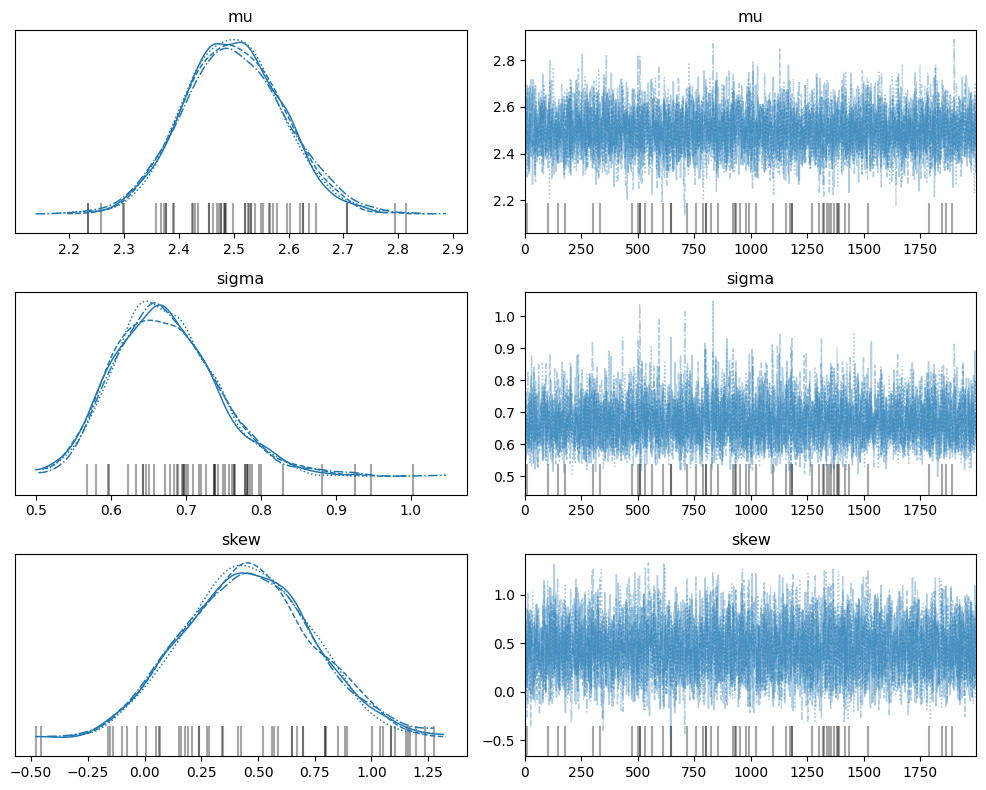

In [4]:
plot_trace(idata_lp3);
plt.show()

## Flood Frequency Curve

Note that return levels are back-transformed from log-space to m3/s for plotting.

E:\GitHub\pyFloodExtremes\src\flood_ffa\lp3\plots.py:56: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = idata.posterior.dims['chain']
E:\GitHub\pyFloodExtremes\src\flood_ffa\lp3\plots.py:57: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_draws = idata.posterior.dims['draw']


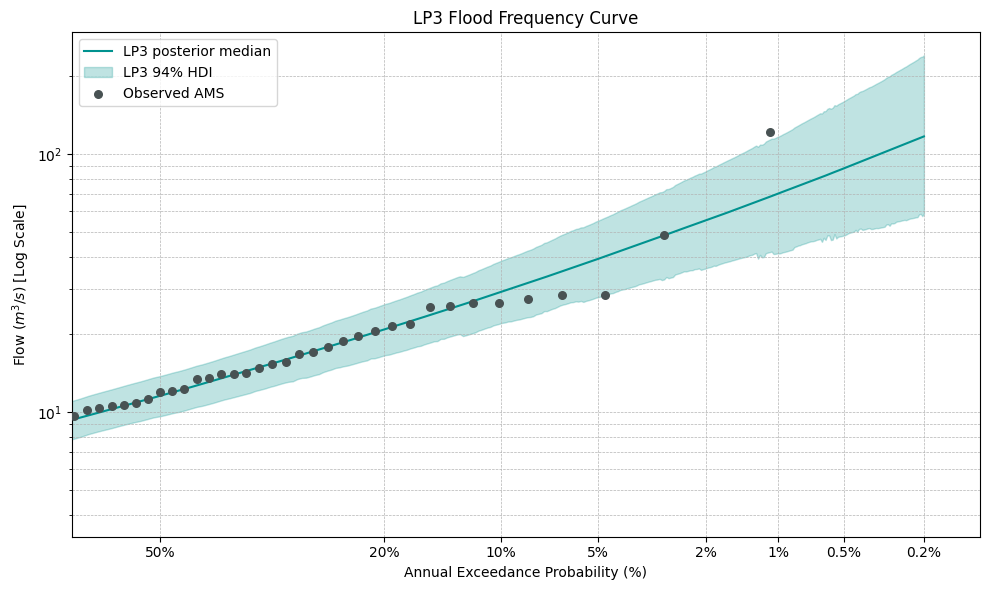

In [5]:
plot_return_levels(idata_lp3, flows);
plt.show()

In [8]:
idata_lp3


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

## Parameter Summary

In [6]:
az.summary(idata_lp3, hdi_prob=0.94)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,2.499,0.092,2.334,2.676,0.001,0.001,5436.0,4363.0,1.0
skew,0.456,0.281,-0.087,0.963,0.004,0.003,4484.0,4575.0,1.0
sigma,0.673,0.069,0.551,0.803,0.001,0.001,4874.0,4577.0,1.0
